## 1. Preprocessing

Load json and preprocess json in chunks by streaming to avoid OOM errors. 

In [3]:
import pandas as pd

sample = pd.read_json(
    "../data/arxiv-metadata-oai-snapshot.json",
    lines=True,
    nrows=5
)

sample.head(5)

,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,704.0001,Pavel Nadolsky,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Calculation of prompt diphoton production cros...,"37 pages, 15 figures; published version","Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,ANL-HEP-PR-07-12,hep-ph,NaN,A fully differential calculation in perturba...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2008-11-26,"[[Balázs, C., ], [Berger, E. L., ], [Nadolsky,..."
1,704.0002,Louis Theran,Ileana Streinu and Louis Theran,Sparsity-certifying Graph Decompositions,To appear in Graphs and Combinatorics,NaN,NaN,NaN,math.CO cs.CG,http://arxiv.org/licenses/nonexclusive-distrib...,"We describe a new algorithm, the $(k,\ell)$-...","[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2008-12-13,"[[Streinu, Ileana, ], [Theran, Louis, ]]"
2,704.0003,Hongjun Pan,Hongjun Pan,The evolution of the Earth-Moon system based o...,"23 pages, 3 figures",NaN,NaN,NaN,physics.gen-ph,NaN,The evolution of Earth-Moon system is descri...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2008-01-13,"[[Pan, Hongjun, ]]"
3,704.0004,David Callan,David Callan,A determinant of Stirling cycle numbers counts...,11 pages,NaN,NaN,NaN,math.CO,NaN,We show that a determinant of Stirling cycle...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2007-05-23,"[[Callan, David, ]]"
4,704.0005,Alberto Torchinsky,Wael Abu-Shammala and Alberto Torchinsky,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,NaN,"Illinois J. Math. 52 (2008) no.2, 681-689",NaN,NaN,math.CA math.FA,NaN,In this paper we show how to compute the $\L...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2013-10-15,"[[Abu-Shammala, Wael, ], [Torchinsky, Alberto, ]]"


In [4]:
import pandas as pd
import json
from collections import Counter
import matplotlib.pyplot as plt

input_path = "../data/arxiv-metadata-oai-snapshot.json"
output_path = "../data/papers_clean.jsonl"

keep_cols = ["id", "title", "abstract", "authors", "categories", "update_date"]

chunksize = 10000
category_counter = Counter()

with open(output_path, "w", encoding="utf-8") as out:
    for chunk in pd.read_json(input_path, lines=True, chunksize=chunksize):

        # Keep only needed columns
        chunk = chunk[keep_cols].copy()

        # Clean text fields
        chunk["title"] = chunk["title"].fillna("").str.strip()
        chunk["abstract"] = chunk["abstract"].fillna("").str.strip()
        chunk["authors"] = chunk["authors"].fillna("").str.strip()
        chunk["categories"] = chunk["categories"].fillna("").str.strip()

        # Filter bad rows
        chunk = chunk[(chunk["title"] != "") & (chunk["abstract"] != "")]
        chunk = chunk[chunk["abstract"].str.len() >= 50]

        # --- UPDATE CATEGORY COUNTS ---
        for cats in chunk["categories"]:
            for c in cats.split():
                category_counter[c] += 1

        # --- SAVE CLEANED DATA ---
        for record in chunk.to_dict(orient="records"):
            out.write(json.dumps(record, ensure_ascii=False) + "\n")

print("Preprocessing done")

Preprocessing done


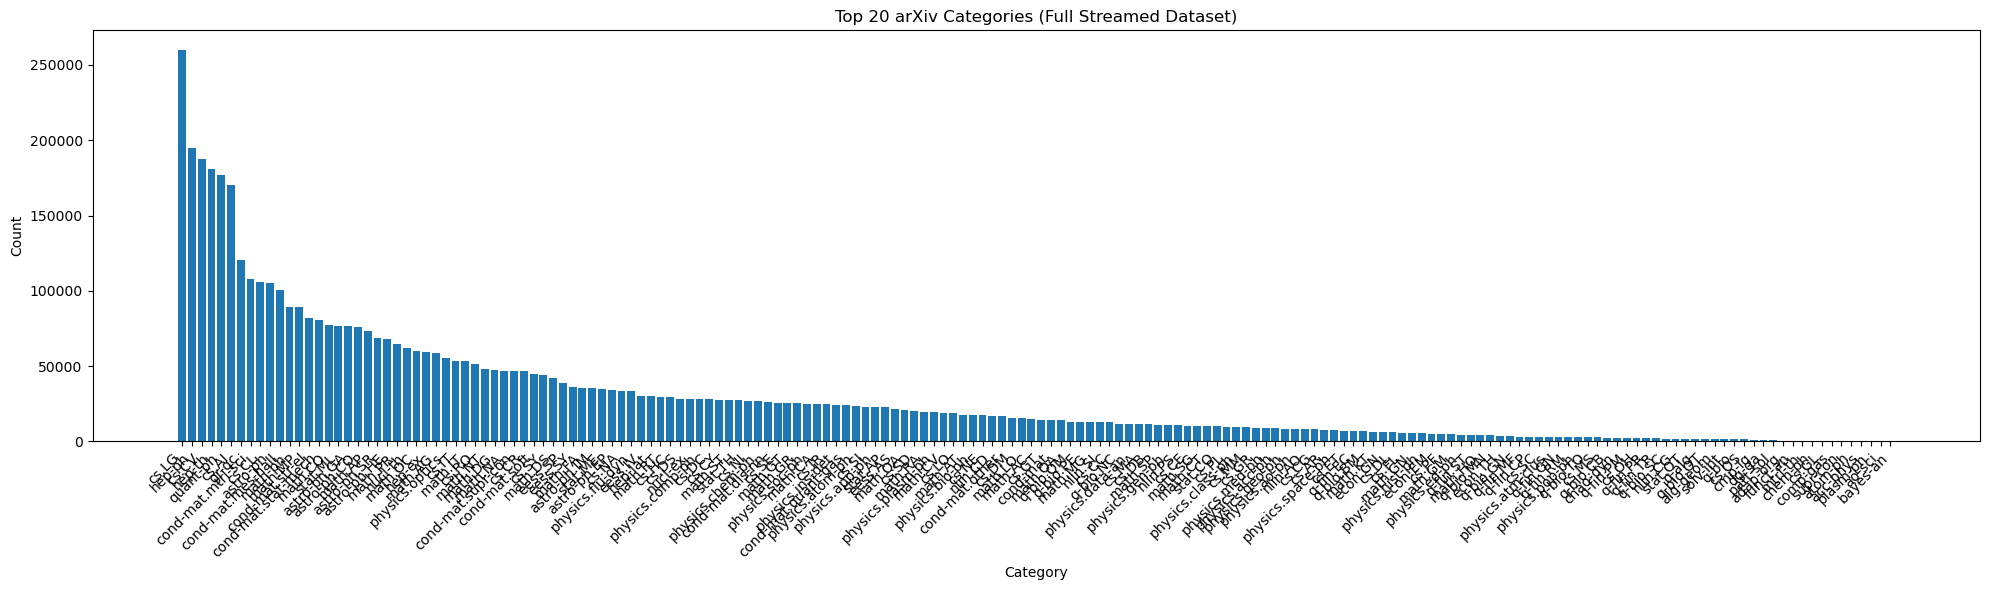

In [5]:
top_categories = category_counter.most_common(1000)

labels = [x[0] for x in top_categories]
values = [x[1] for x in top_categories]

plt.figure(figsize=(20, 6))
plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.title("Top 20 arXiv Categories (Full Streamed Dataset)")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [6]:
cs_lg_count = dict(top_categories).get("cs.LG", 0)
cs_cl_count = dict(top_categories).get("cs.CL", 0)

# q-bio is multiple categories → sum them
q_bio_count = sum(count for cat, count in top_categories if cat.startswith("q-bio"))

for cat, count in top_categories:
    if cat.startswith("q-bio"):
        print(cat)

print("cs.LG:", cs_lg_count)
print("cs.CL:", cs_cl_count)
print("q-bio (total):", q_bio_count)

q-bio.QM
q-bio.PE
q-bio.NC
q-bio.BM
q-bio.MN
q-bio.GN
q-bio.TO
q-bio.CB
q-bio.SC
q-bio.OT
q-bio
cs.LG: 259965
cs.CL: 105531
q-bio (total): 61878


In [7]:
cat_dict = dict(top_categories)

selected_categories = [
    "cs.LG",
    "cs.CL",
    "cs.IR",
    "q-bio.NC",
    "q-bio.QM",
    "q-bio.GN",
    "q-bio.MN"
]

for cat in selected_categories:
    print(f"{cat}: {cat_dict.get(cat, 0)}")

cs.LG: 259965
cs.CL: 105531
cs.IR: 24534
q-bio.NC: 11861
q-bio.QM: 12913
q-bio.GN: 3763
q-bio.MN: 4114


In [8]:
total = sum(cat_dict.get(cat, 0) for cat in selected_categories)
print("\nTotal:", total)


Total: 422681


In [ ]:
selected_pattern = r"cs\.LG|cs\.CL|cs\.IR|q-bio\.NC|q-bio\.QM|q-bio\.GN|q-bio\.MN"

filtered_df = df[df["categories"].str.contains(selected_pattern, na=False)]
print("Unique matching papers:", len(filtered_df))